## **Feature engineering**

In [ ]:
import gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from joblib import Parallel, delayed
from tqdm.auto import tqdm

from scipy.spatial.distance import cosine
from scipy.sparse import hstack

import spacy
from better_profanity import profanity
from detoxify import Detoxify
from sentence_transformers import SentenceTransformer
from transformers import pipeline, DistilBertTokenizer, DistilBertModel

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [2]:
# Load dataset
df = pd.read_csv('sampled_mental_dataset.csv')

## Data Normalization

In [ ]:
def process_data():
    # Load the spaCy model while disabling the 'parser', 'ner', and 'tagger' components, keeping only the tokenizer and lemmatizer active
    nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner', 'tagger'])
    
    # nlp.pipe processes the 'text' column as a stream of strings
    # It divides the work across 6 CPU cores and handles 500 texts per batch
    docs = nlp.pipe(df['text'].astype(str), batch_size=500, n_process=6)

    cleaned_texts = []
    
    # Loop through the processed Doc objects, starting the counter 'i' at 1
    for i, doc in enumerate(docs, 1):
        # Create a list of lemmatized, lowercase words, but only if they are 
        # not defined as stop words or punctuation
        tokens = [token.lemma_.lower() for token in doc 
                  if not token.is_stop and not token.is_punct]
        
        # Rejoin the list of cleaned tokens into a single string separated by spaces
        cleaned_texts.append(" ".join(tokens))
        
        # Every 10,000 iterations, print a status update to the console
        if i % 10000 == 0:
            print(f"Processed {i} texts...")
    
    # Return the full list of cleaned strings
    return cleaned_texts

# Ensures multiprocessing works correctly on Windows
if __name__ == '__main__':
    try:
        # Execute the processing function and store the result in a new dataframe column
        df['cleaned_text'] = process_data()
        print("Success!")
    except Exception as e:
        # Catch and print any errors that occur during the execution
        print(f"Error encountered: {e}")

Processed 10000 texts...
Processed 20000 texts...
Processed 30000 texts...
Success!


## Pre-split feature extraction

### Cleaned Text Length


In [4]:
df['cleaned_text_length'] = df['cleaned_text'].apply(lambda x: len(str(x).split()))

In [5]:
df[['text','text_length','cleaned_text','cleaned_text_length']]

,text,text_length,cleaned_text,cleaned_text_length
0,I've had 4 in last year and noone knows. The l...,496,4 year knows closest gotten getting help yeah ...,39
1,i saw this tiktok trend where you carve pumpki...,1435,saw tiktok trend carve pumpkins head photoshoo...,113
2,Simple-type schizophrenia is characterized by ...,249,simple type schizophrenia characterized negati...,23
3,I m not sure if anything in here will be a tri...,959,m sure trigger read risk hi recently know seve...,63
4,Okay so I know this is a stupid situation but ...,610,okay know stupid situation panicking normally ...,42
...,...,...,...,...
39971,I'm currently in a position with my partner wh...,1183,currently position partner absolutely desperat...,85
39972,"Hello, I really don't know where to go for thi...",1117,hello know want actual answers people experien...,74
39973,Hello again! I just wanted to come on here and...,334,hello wanted come ask people play sports team ...,27
39974,It works so well for me! It makes the rational...,862,works makes rational brain fast emotional brai...,76


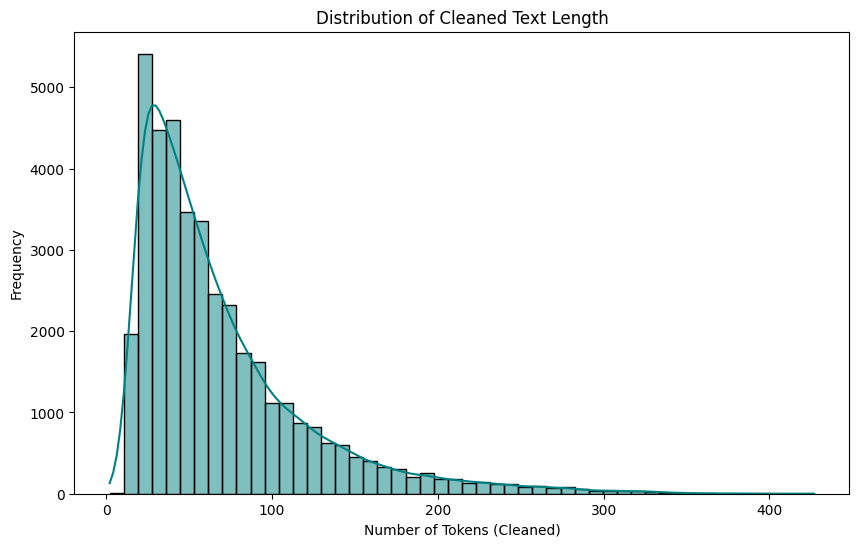

In [ ]:
# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['cleaned_text_length'], bins=50, kde=True, color='teal')
plt.title('Distribution of Cleaned Text Length')
plt.xlabel('Number of Tokens (Cleaned)')
plt.ylabel('Frequency')
plt.show()

### Standardized Type-Token Ratio

In [ ]:
def calculate_sttr_batch(texts, window_size=200):
    # Load spaCy model with only the tokenizer enabled for maximum speed
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "lemmatizer", "attribute_ruler"])
    
    results = []
    # Use nlp.pipe to process the stream of texts efficiently in batches
    for doc in nlp.pipe(texts, batch_size=100):
        # Convert the spaCy Doc into a list of raw text tokens
        tokens = [token.text for token in doc]
        
        # Handle empty documents
        if len(tokens) == 0:
            results.append(0.0)
            continue
        
        # If the text is shorter than the window, return the basic TTR
        if len(tokens) < window_size:
            results.append(len(set(tokens)) / len(tokens))
            continue
        
        # STTR: Calculate TTR for every non-overlapping window of 200 words.
        # This standardizes the score across texts of different lengths
        ttr_values = [
            len(set(tokens[i : i + window_size])) / window_size
            for i in range(0, len(tokens) - window_size + 1, window_size)
        ]
        
        # The final STTR is the average of all window TTRs.
        results.append(np.mean(ttr_values) if ttr_values else 0.0)
    
    return results


if __name__ == "__main__":
    NUM_CORE = 6
    CHUNK_SIZE = 5000  # Size of data chunks sent to each CPU core.
    
    print(f"Starting work on {len(df)} rows using {NUM_CORE} cores...")
    
    # Split the dataframe column into a list of chunks
    # Parallel processing works better with large chunks rather than individual rows
    chunks = [df['cleaned_text'].iloc[i:i+CHUNK_SIZE].tolist() 
              for i in range(0, len(df), CHUNK_SIZE)]
    
    # Execute the processing in parallel:
    # - n_jobs = 6: Runs 6 parallel Python processes
    # - delayed(): Prepares the function for parallel execution
    # - tqdm(): Displays a progress bar for the chunks
    results = Parallel(n_jobs=NUM_CORE)(
        delayed(calculate_sttr_batch)(chunk) 
        for chunk in tqdm(chunks, desc="Chunks")
    )
    
    # Flatten the list of lists (results) into a single flat list for the dataframe
    df['sttr'] = [item for sublist in results for item in sublist]
    print("Completed!")

Starting work on 39976 rows using 6 cores...


Chunks: 100%|██████████| 8/8 [00:00<00:00, 112.96it/s]


Completed!


In [8]:
df["sttr"].head(20)

0     0.871795
1     0.716814
2     0.956522
3     0.857143
4     0.761905
5     0.916667
6     1.000000
7     0.635000
8     0.651163
9     0.647619
10    0.886364
11    0.866667
12    0.897436
13    0.857143
14    0.846154
15    0.650794
16    0.846847
17    0.833333
18    0.755102
19    1.000000
Name: sttr, dtype: float64

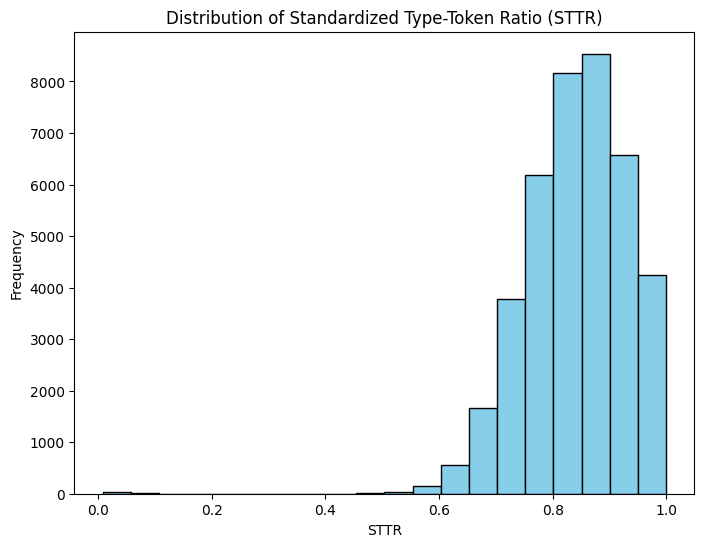

STTR calculated for 39976 texts


In [ ]:
# Plot the distribution of sttr values as a histogram
plt.figure(figsize=(8,6))
plt.hist(df['sttr'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Standardized Type-Token Ratio (STTR)')
plt.xlabel('STTR')
plt.ylabel('Frequency')
plt.show()
print(f"STTR calculated for {len(df)} texts")

### Emotion detection

In [ ]:
# Final safety check for hardware acceleration
# device = 0 targets the first available GPU, -1 defaults to CPU
device = 0 if torch.cuda.is_available() else -1
print(f"Working on: {'GPU RTX 4050' if device == 0 else 'CPU'}")

# We use the Hugging Face 'pipeline' for ease of use
classifier = pipeline(
    task="text-classification", 
    model="SamLowe/roberta-base-go_emotions", 
    top_k=1,            # Only return the single most likely emotion
    truncation=True,    # Ensure texts longer than 512 tokens don't crash the model
    device=device,
    # Use float16 (Half Precision) to utilize the RTX 4050's Tensor Cores and save VRAM
    model_kwargs={"torch_dtype": torch.float16} 
)

# Convert the dataframe column to a list of strings for the pipeline
texts = df['text'].astype(str).tolist()

# batch_size = 64 sends 64 texts to the GPU at once, significantly increasing throughout
predictions = []

print("Analyzing emotions...")
# Iterate through the generator created by the classifier
for out in tqdm(classifier(texts, batch_size=64), total=len(texts)):
    # Extract the label from the top prediction
    predictions.append(out[0]['label'])

# Add the resulting list as a new column in the original DataFrame
df['predicted_emotion'] = predictions
print("Operation completed successfully!")

Working on: GPU RTX 4050


`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda:0


Analyzing emotions...


  0%|          | 0/39976 [00:00<?, ?it/s]

Operation completed successfully!


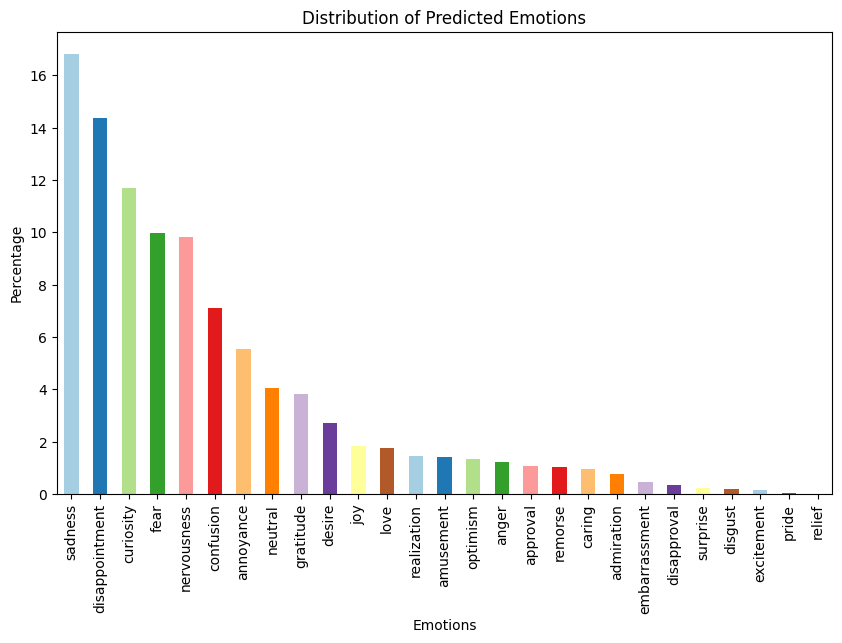

In [ ]:
# Plot the distribution of predicted emotions (percentages) using a bar chart and different colors for each bar
emotion_counts = df['predicted_emotion'].value_counts(normalize=True) * 100
plt.figure(figsize=(10,6))
emotion_counts.plot(kind='bar', color=plt.cm.Paired.colors)
plt.title('Distribution of Predicted Emotions')
plt.xlabel('Emotions')
plt.ylabel('Percentage')
plt.show()

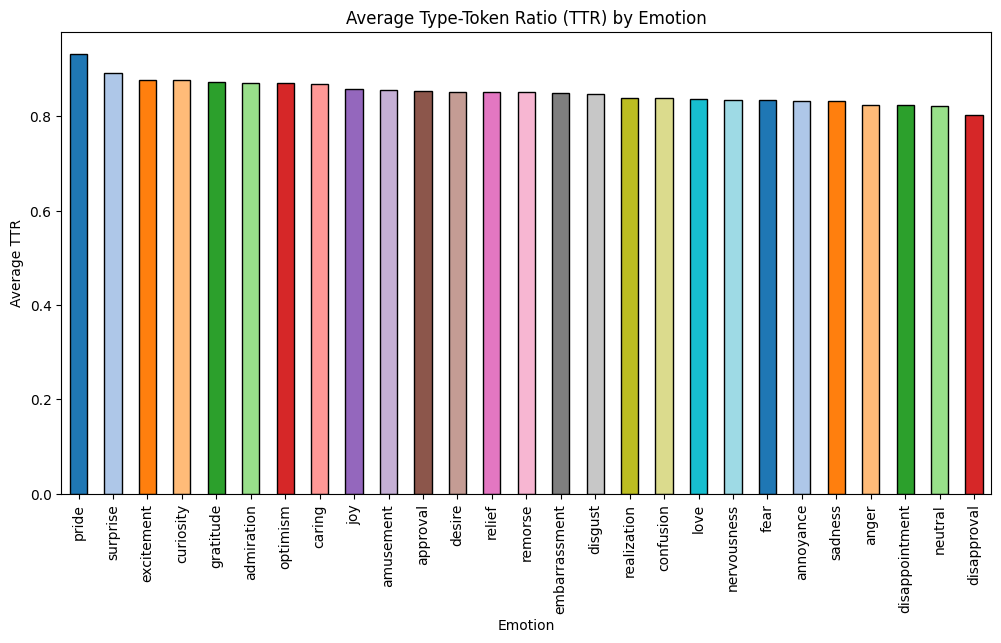

In [12]:
# Analyze the distribution of Type-Token Ratio (TTR) across different emotions
mean_ttr = df.groupby('predicted_emotion')['sttr'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

# Use a colormap for different colors per bar
colors = plt.cm.tab20.colors  # tab20 has 20 distinct colors
mean_ttr.plot(kind='bar', color=colors[:len(mean_ttr)], edgecolor='black')

plt.title('Average Type-Token Ratio (TTR) by Emotion')
plt.xlabel('Emotion')
plt.ylabel('Average TTR')
plt.show()

### Average sentence length

In [ ]:
def calculate_avg_sentence_batch(texts):
    """
    Processes a batch of texts using nlp.pipe, optimized to 
    prevent memory issues and multiprocessing errors.
    """
    # Load the spaCy model inside the function to ensure each process has its own instance
    # Keep the "parser" enabled because it is responsible for sentence segmentation (doc.sents)
    nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer", "attribute_ruler"])
    
    results = []
    # nlp.pipe handles the texts in the chunk efficiently using internal batching
    for doc in nlp.pipe(texts, batch_size=100):
        # Identify individual sentences within the document
        sentences = list(doc.sents)
        
        # Handle cases where the text might be empty or unparseable
        if len(sentences) == 0:
            results.append(0.0)
            continue
            
        # Sum the number of tokens in every sentence and divide by the total number of sentences
        total_tokens = sum(len(sent) for sent in sentences)
        avg_len = total_tokens / len(sentences)
        results.append(avg_len)
        
    return results


if __name__ == "__main__":
    NUM_CORE = 6
    CHUNK_SIZE = 2000  # Size of data chunks to balance speed and RAM usage
    
    print(f"Starting average sentence length calculation on {len(df)} rows using {NUM_CORE} cores...")
    
    # Divide the dataframe column into chunks (lists of strings)
    chunks = [df['text'].iloc[i:i + CHUNK_SIZE].astype(str).tolist() 
              for i in range(0, len(df), CHUNK_SIZE)]
    
    # Process chunks in parallel using Joblib and track progress with tqdm.
    # Parallel(n_jobs = 6) spawns 6 independent Python processes.
    results = Parallel(n_jobs=NUM_CORE)(
        delayed(calculate_avg_sentence_batch)(chunk) 
        for chunk in tqdm(chunks, desc="Processing chunks")
    )
    
    # Flatten the list of lists (the chunks) back into a single column.
    df['avg_sentence_length'] = [item for sublist in results for item in sublist]
    
    print("Completed!")

Starting average sentence length calculation on 39976 rows using 6 cores...


Processing chunks:   0%|          | 0/20 [00:00<?, ?it/s]

Completed!


In [14]:
df["avg_sentence_length"].head()

0     8.769231
1    23.533333
2    48.000000
3    15.583333
4    15.444444
Name: avg_sentence_length, dtype: float64

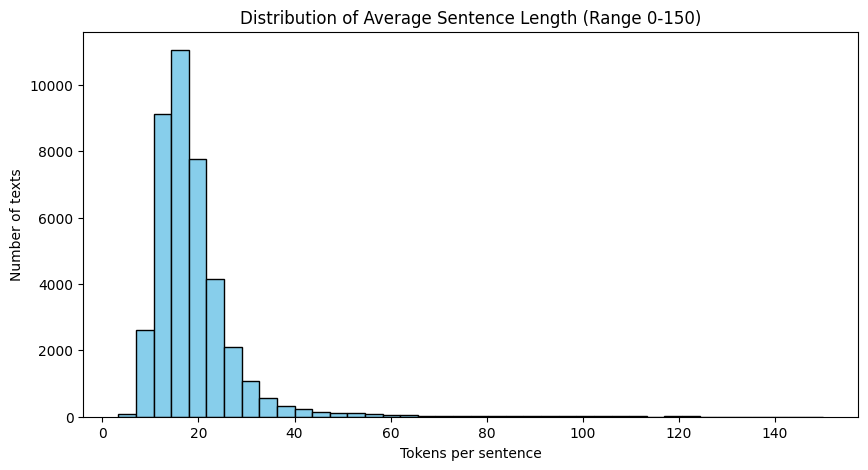

In [ ]:
# We select only the data where the average sentence length is 150 tokens or fewer.
# This prevents extremely long, potentially malformed texts from squashing the histogram.
filtered_data = df[df['avg_sentence_length'] <= 150]['avg_sentence_length']

plt.figure(figsize=(10, 5))

# Create the histogram
plt.hist(filtered_data, bins=40, color='skyblue', edgecolor='black')

# Essential labels
plt.title(f'Distribution of Average Sentence Length (Range 0-150)')
plt.xlabel('Tokens per sentence')
plt.ylabel('Number of texts')

# Render the final plot
plt.show()

### Average sentence coherence


In [ ]:
# Hardware setup: 0 refers to RTX 4050
device = 0 if torch.cuda.is_available() else -1
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', device=device)
# Parser is required for sentence segmentation (doc.sents)
nlp = spacy.load("en_core_web_sm", disable=["ner", "lemmatizer", "attribute_ruler", "tagger"])

def get_coherence(df_column, batch_size=128):
    # Sentence Segmentation (CPU task)
    print("Segmenting sentences...")
    all_docs_sentences = []
    flat_sentences = []
    
    # Send texts through spaCy's nlp.pipe for efficient multi-core processing
    for doc in tqdm(nlp.pipe(df_column.astype(str), batch_size=500, n_process=6), total=len(df_column)):
        sentences = [sent.text for sent in doc.sents]
        all_docs_sentences.append(sentences)
        # Collect ALL sentences in a single flat list for the GPU
        flat_sentences.extend(sentences) 

    # Massive GPU Encoding for all sentences at once
    print(f"Encoding {len(flat_sentences)} sentences on GPU...")
    all_embeddings = model.encode(
        flat_sentences, 
        batch_size=batch_size,  # Processing 128 sentences simultaneously
        convert_to_tensor=True, # Keeps data on GPU memory for the next step
        show_progress_bar=True
    )

    # Fast Similarity Calculation (Vectorized)
    print("Calculating coherence scores...")
    scores = []
    cursor = 0 # Pointer to track which sentences belong to which document
    for sentences in all_docs_sentences:
        n = len(sentences)
        if n < 2:
            scores.append(1.0) # Standard score for single-sentence texts
            cursor += n
            continue
        
        # Slice the pre-calculated embeddings for the current document
        doc_emb = all_embeddings[cursor : cursor + n]
        
        # Calculate cosine similarity for all consecutive pairs in a single GPU operation
        sims = torch.nn.functional.cosine_similarity(doc_emb[:-1], doc_emb[1:])
        scores.append(sims.mean().item())
        
        # Move the pointer to the next document's sentences
        cursor += n

        # Free GPU memory every 1000 documents to prevent VRAM saturation
        if len(scores) % 1000 == 0:
            torch.cuda.empty_cache()
        
    return scores

if __name__ == "__main__":
    # 128 is the right choice for 6GB of VRAM to ensure stability and speed
    df['avg_sentence_coherence'] = get_coherence(df['text'], batch_size=128)
    print("Coherence calculation complete with full GPU acceleration!")

Segmenting sentences...


  0%|          | 0/39976 [00:00<?, ?it/s]

Encoding 452242 sentences on GPU...


Batches:   0%|          | 0/3534 [00:00<?, ?it/s]

Calculating coherence scores...
Coherence calculation complete with full GPU acceleration!


In [17]:
df["avg_sentence_coherence"].head(20)

0     0.270417
1     0.303381
2     1.000000
3     0.264229
4     0.256448
5     0.293835
6     0.192566
7     0.316166
8     0.301854
9     0.347051
10    0.489052
11    0.400803
12    0.242027
13    1.000000
14    0.396337
15    0.365601
16    0.310693
17    0.311362
18    0.232386
19    0.094772
Name: avg_sentence_coherence, dtype: float64

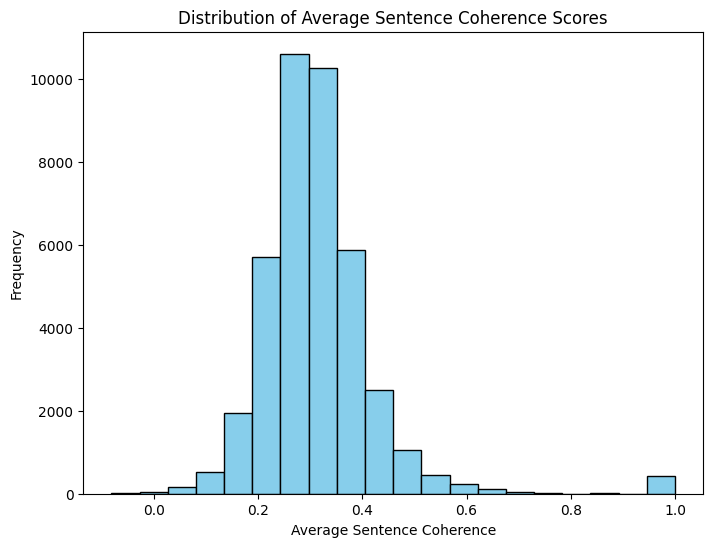

Average sentence coherence calculated for 39976 texts


In [ ]:
# Plot the coherence scores distribution as a histogram
plt.figure(figsize=(8,6))
plt.hist(df['avg_sentence_coherence'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Average Sentence Coherence Scores')
plt.xlabel('Average Sentence Coherence')
plt.ylabel('Frequency')
plt.show()
print(f"Average sentence coherence calculated for {len(df)} texts")

### Toxicity

In [ ]:
# The 'original' model is a BERT-based transformer that outputs probability scores
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading Detoxify model on: {device}")
model = Detoxify('original', device=device)

# Using a batch size of 64 balances speed and VRAM usage (6GB total on your 4050)
BATCH_SIZE = 64
MAX_CHAR_LENGTH = 2000 # Limit to first 2000 characters for BERT compatibility

print("Preparing texts and applying manual truncation...")
# Pre-processing: convert to string, handle NaNs, and truncate long strings
texts = [
    str(t)[:MAX_CHAR_LENGTH] if len(str(t)) > MAX_CHAR_LENGTH else str(t) 
    for t in df['text'].fillna("").tolist()
]

results = []

# Processing in batches rather than one text at a time
for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="GPU Toxicity Scoring"):
    # Create the current batch slice
    batch = texts[i : i + BATCH_SIZE]
    
    # model.predict(batch) returns a dictionary of lists.
    # Each list contains the raw probability (0.0 to 1.0) for a specific category
    predictions = model.predict(batch)
    
    # Extract the numerical 'toxicity' scores directly
    batch_scores = predictions['toxicity']
    
    # Collect the numerical scores for the final assignment
    results.extend(batch_scores)

# We assign the list of floats to a new column
df['toxicity_score'] = results

print(f"Success! Processed {len(df)} rows. Numerical toxicity scores saved.")

Loading Detoxify model on: cuda
Preparing texts and applying manual truncation...


GPU Toxicity Scoring:   0%|          | 0/625 [00:00<?, ?it/s]

Success! Processed 39976 rows. Numerical toxicity scores saved.


In [20]:
# Logit transformation to spread out values near 0 and 1
epsilon = 1e-5
df['toxicity_score_log'] = np.log((df['toxicity_score'] + epsilon) / (1 - df['toxicity_score'] + epsilon))


# The more the values are negative, the less toxic the text is; the more positive, the more toxic.
df['toxicity_score_log'].head(20)

0    -7.218295
1    -1.843325
2    -4.969488
3    -1.981752
4    -4.348233
5    -6.282076
6    -7.096641
7    -4.247374
8    -2.391551
9     2.920287
10   -2.215040
11   -2.088820
12   -5.689986
13   -7.203869
14   -7.384341
15   -7.236609
16   -5.829254
17   -4.236830
18   -6.974211
19   -2.064886
Name: toxicity_score_log, dtype: float64

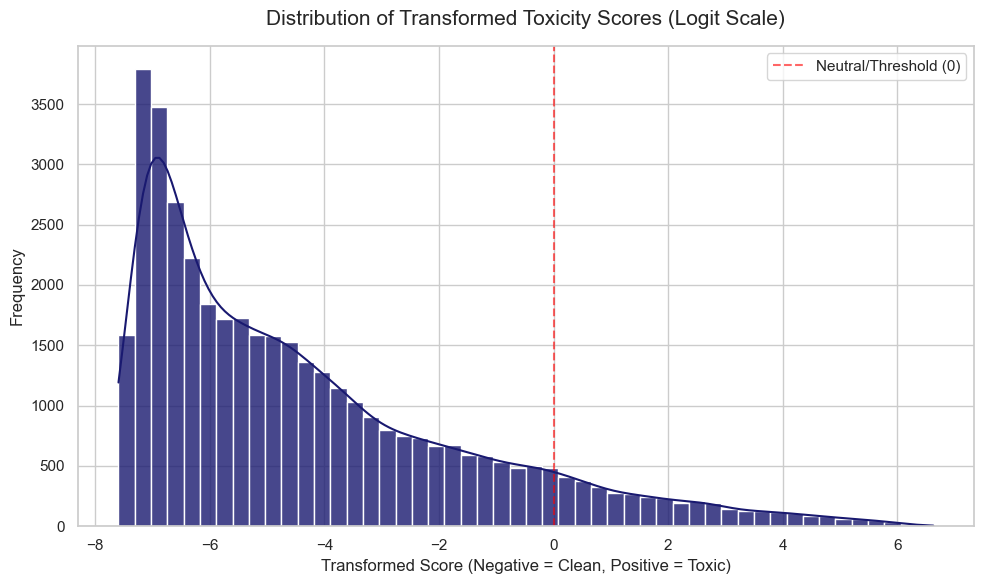

In [21]:
# Plotting the distribution of transformed toxicity scores (logit scale)
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Create the histogram with a KDE curve
sns.histplot(df['toxicity_score_log'], bins=50, kde=True, color='midnightblue', alpha=0.8)

# Add a vertical line at zero to visually separate "Clean" from "Toxic"
plt.axvline(x=0, color='red', linestyle='--', alpha=0.6, label='Neutral/Threshold (0)')

# Titles and Labels
plt.title('Distribution of Transformed Toxicity Scores (Logit Scale)', fontsize=15, pad=15)
plt.xlabel('Transformed Score (Negative = Clean, Positive = Toxic)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

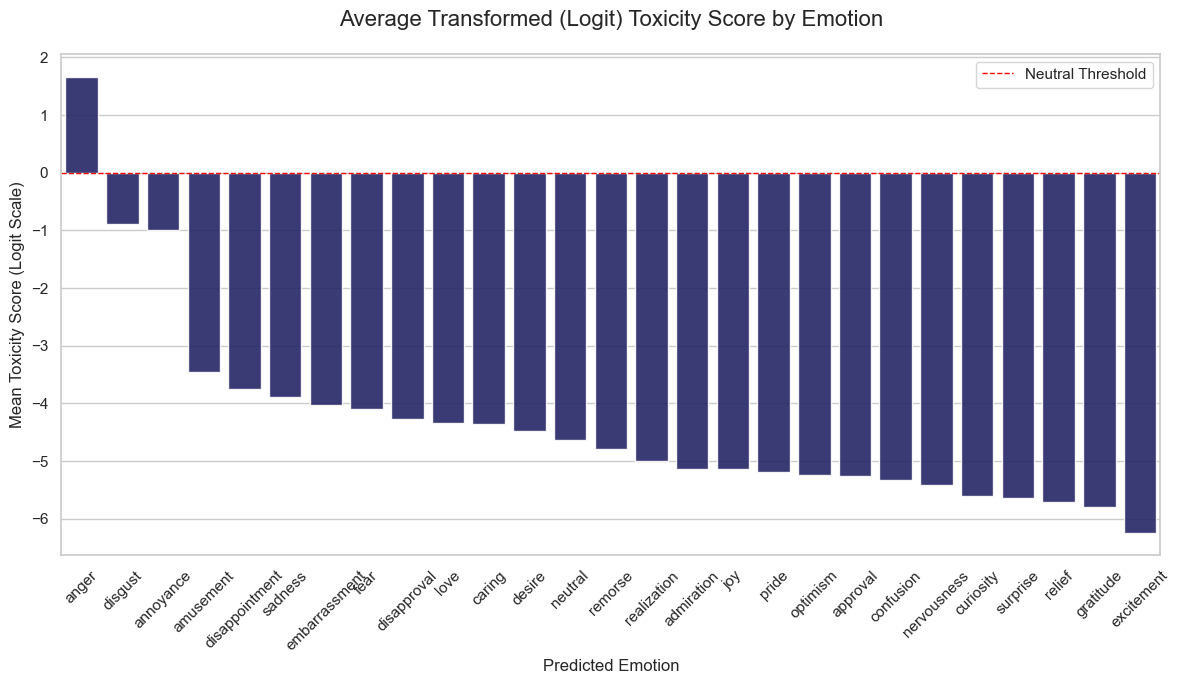

In [22]:
# Bar Plot: Average Transformed (Logit) Toxicity by Emotion

# Calculate the mean of the transformed toxicity for each emotion
# We sort them so the "most toxic" emotions appear on the left
emotion_means = df.groupby('predicted_emotion')['toxicity_score_log'].mean().sort_values(ascending=False)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Bar Plot
sns.barplot(
    x=emotion_means.index, 
    y=emotion_means.values, 
    color='midnightblue',
    alpha=0.9
)

# Add a horizontal line at 0 (the neutral threshold)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Neutral Threshold')

plt.title('Average Transformed (Logit) Toxicity Score by Emotion', fontsize=16, pad=20)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.ylabel('Mean Toxicity Score (Logit Scale)', fontsize=12)
plt.xticks(rotation=45) # Rotates labels to prevent overlapping
plt.legend()

plt.tight_layout()
plt.show()

### Polarity

In [ ]:
# Setup device
device = 0 if torch.cuda.is_available() else -1
print(f"Loading Sentiment model on: {'cuda' if device == 0 else 'cpu'}")

# Initialize pipeline with GPU support
classifier = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    device=device,          # Moves the model to GPU
    truncation=True,
    max_length=512
)

label_map = {
    "LABEL_0": "negative",
    "LABEL_1": "neutral",
    "LABEL_2": "positive"
}

# Ensure all texts are strings and handle empty values
texts = df['text'].fillna("").astype(str).tolist()

# Using a batch_size here is the key to GPU speed
BATCH_SIZE = 64 
results = []

print("Starting GPU Sentiment Analysis...")
# We pass the list directly to the classifier; it returns a generator
for out in tqdm(classifier(texts, batch_size=BATCH_SIZE), total=len(texts)):
    results.append(label_map[out['label']])

# Assign back to dataframe
df["polarity"] = results

print(f"Success! Sentiment analysis complete for {len(df)} rows.")

Loading Sentiment model on: cuda


Device set to use cuda:0


Starting GPU Sentiment Analysis...


  0%|          | 0/39976 [00:00<?, ?it/s]

Success! Sentiment analysis complete for 39976 rows.


In [24]:
df["polarity"].head(20)

0     negative
1      neutral
2     negative
3     negative
4     negative
5     negative
6     negative
7     negative
8     negative
9     negative
10    negative
11    negative
12    negative
13    negative
14     neutral
15    positive
16    negative
17    negative
18     neutral
19    negative
Name: polarity, dtype: object

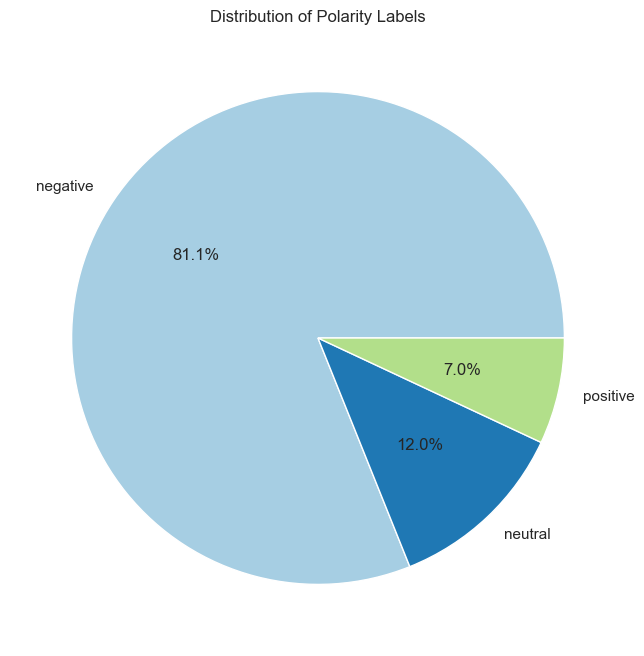

In [ ]:
# Create a pie chart showing the distribution of polarity labels
polarity_counts = df['polarity'].value_counts(normalize=True) * 100
plt.figure(figsize=(8,8))
polarity_counts.plot(kind='pie', autopct='%1.1f%%', colors=plt.cm.Paired.colors)
plt.title('Distribution of Polarity Labels')
plt.ylabel('')
plt.show()

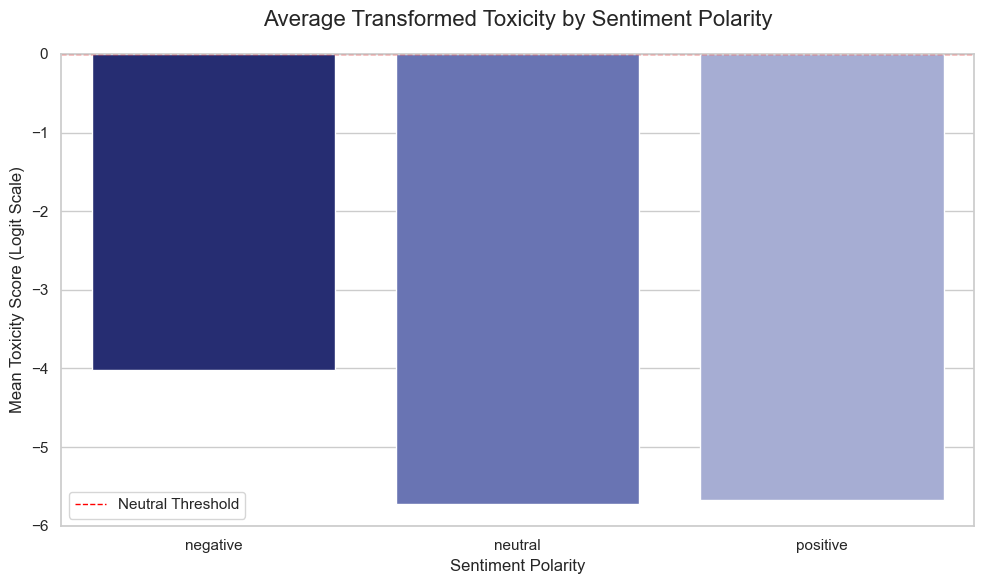

In [26]:
# Bar Plot: Average Transformed Toxicity by Sentiment Polarity

# We sort them: usually Negative > Neutral > Positive
polarity_order = ['negative', 'neutral', 'positive']
polarity_means = df.groupby('polarity')['toxicity_score_log'].mean().reindex(polarity_order)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the Bar Plot
sns.barplot(
    x=polarity_means.index, 
    y=polarity_means.values, 
    palette=['#1a237e', '#5c6bc0', '#9fa8da'], # Custom dark blue shades
    hue=polarity_means.index,
    legend=False
)

# Add the horizontal line at 0 (the neutral threshold)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Neutral Threshold')

plt.title('Average Transformed Toxicity by Sentiment Polarity', fontsize=16, pad=20)
plt.xlabel('Sentiment Polarity', fontsize=12)
plt.ylabel('Mean Toxicity Score (Logit Scale)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

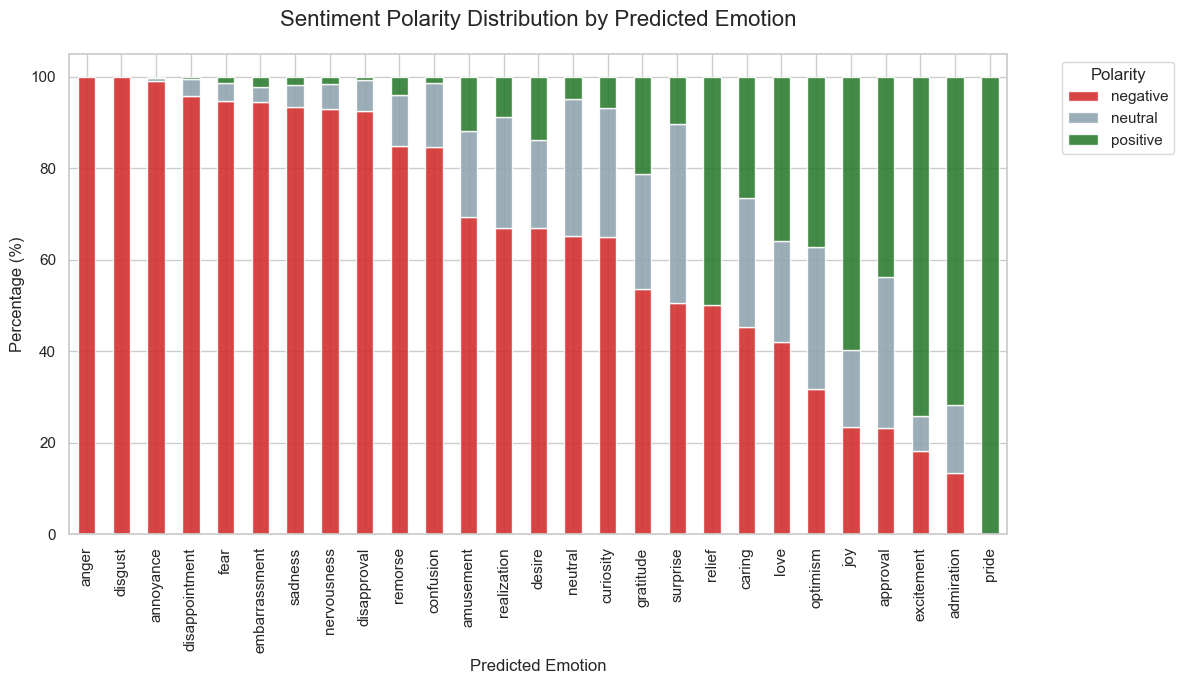

In [27]:
# Create a contingency table (percentages)
# This calculates what % of each emotion falls into which polarity
contingency_pct = pd.crosstab(df['predicted_emotion'], df['polarity'], normalize='index') * 100

# Sort by negative percentage to make the chart look organized
contingency_pct = contingency_pct.sort_values(by='negative', ascending=False)

# Plotting
sns.set_theme(style="whitegrid")
ax = contingency_pct.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 7),
    color=['#d32f2f', '#90a4ae', '#2e7d32'], # Dark red, grey, dark green
    alpha=0.9
)

plt.title('Sentiment Polarity Distribution by Predicted Emotion', fontsize=16, pad=20)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Polarity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Split (train-test)

In [ ]:
# Sort the DataFrame by index to ensure the input order is deterministic
# Without this, if the CSV loading order varies slightly, 'random_state' might not guarantee the exact same split across different runs/files
df = df.sort_index()

# Define Features (X) and Target (y)
# We separate them here so train_test_split returns 4 distinct variables
y = df['label']                  
X = df.drop(columns=['label'])   

# Perform the train-test split
# By passing X and y separately, the function returns 4 arrays/DataFrames
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    stratify=y,       # Ensures the training/test sets have the same class proportions as the original data
    test_size=0.2,    # Allocates 20% of data for testing
    random_state=42,  # Must be the SAME integer in both files for alignment
    shuffle=True      # Shuffles the data before splitting 
)

In [29]:
X_train.shape

(31980, 11)

In [30]:
X_test.shape

(7996, 11)

## Post-split feature extraction & vectorization

### Rare words percentage

In [ ]:
print("Starting word frequency calculation...")  
# Convert the cleaning text column to a numpy array for faster iteration
train_texts = X_train['cleaned_text'].astype(str).values  

# Flatten all texts into a single list of tokens to count frequencies
all_tokens = []
for text in tqdm(train_texts, desc="Flattening tokens from Train Set"):
    all_tokens.extend(text.split())  

# Count the occurrences of each word
word_freq = Counter(all_tokens)  

# Define the rarity threshold: words appearing 2 times or less are considered rare
threshold = 5

# Create a set of rare words for O(1) lookup speed
rare_words_set = {
    word for word, count in word_freq.items() 
    if count <= threshold
}  

print(f"Rarity Threshold (fixed): {threshold}") 
print(f"Total rare words identified: {len(rare_words_set)}")   

# Calculate the percentage of rare words in each document
def calculate_rare_words_ratio(texts, rare_words):

    # Pre-allocate a numpy array for better memory management
    results = np.zeros(len(texts), dtype=np.float32)
    
    for i, text in enumerate(tqdm(texts, desc="Calculating Rare Word %")):
        tokens = text.split()
        
        # Avoid division by zero for empty strings
        if not tokens:
            results[i] = 0.0
            continue
        
        # Count how many tokens in the current text exist in the rare_words_set
        rare_count = sum(1 for token in tokens if token in rare_words)
        
        # Convert count to percentage
        results[i] = (rare_count / len(tokens)) * 100
    
    return results   

# We use the rare_words_set derived only from X_train to prevent data leakage into the test set
print("\nProcessing Training Set...")
X_train['rare_words_pct'] = calculate_rare_words_ratio(
    X_train['cleaned_text'].astype(str).values, 
    rare_words_set
)  

print("\nProcessing Test Set...")
X_test['rare_words_pct'] = calculate_rare_words_ratio(
    X_test['cleaned_text'].astype(str).values, 
    rare_words_set
)  

print("\nAll rare word features calculated successfully!")

Starting word frequency calculation...


Flattening tokens from Train Set:   0%|          | 0/31980 [00:00<?, ?it/s]

Rarity Threshold (fixed): 5
Total rare words identified: 30766

Processing Training Set...


Calculating Rare Word %:   0%|          | 0/31980 [00:00<?, ?it/s]


Processing Test Set...


Calculating Rare Word %:   0%|          | 0/7996 [00:00<?, ?it/s]


All rare word features calculated successfully!


In [32]:
X_train["rare_words_pct"].head(20)

19243    0.840336
29982    2.531646
17910    0.000000
18720    0.000000
25858    4.545455
30715    0.000000
38320    0.000000
7915     0.000000
5449     0.000000
30725    6.666667
14446    0.000000
20172    0.000000
29128    3.636364
18983    1.612903
1968     2.380952
11549    0.684932
13438    7.317073
3501     1.369863
25053    0.000000
19994    1.310044
Name: rare_words_pct, dtype: float32

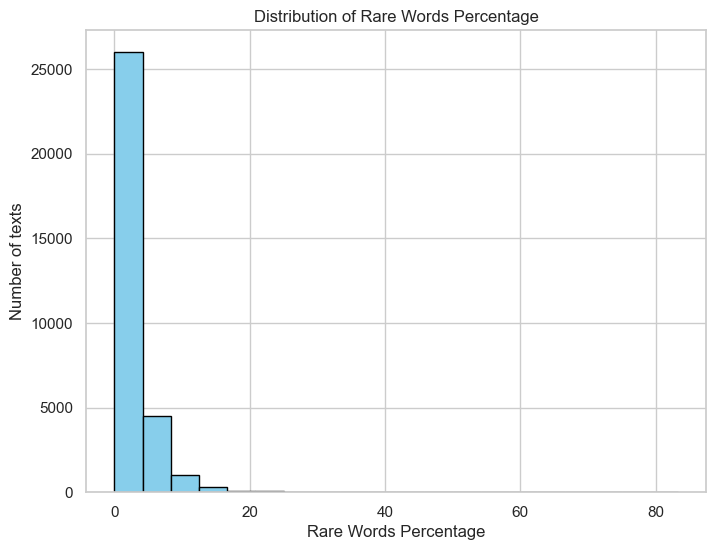

Rare words percentage calculated for 39976 texts


In [ ]:
# Plot the rare words percentage distribution as a histogram in the X_train 

plt.figure(figsize=(8,6))
plt.hist(X_train['rare_words_pct'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Rare Words Percentage')
plt.xlabel('Rare Words Percentage')
plt.ylabel('Number of texts')
plt.show()
print(f"Rare words percentage calculated for {len(df)} texts")

In [34]:
X_train.head(20)

,text,text_length,cleaned_text,cleaned_text_length,sttr,predicted_emotion,avg_sentence_length,avg_sentence_coherence,toxicity_score,toxicity_score_log,polarity,rare_words_pct
19243,"First of all, i don t know how to sound unbias...",1512,don t know sound unbiased don t try advice lik...,119,0.756303,fear,22.428571,0.287959,0.000766,-7.160938,negative,0.840336
29982,I had the worst weekend and am currently still...,904,worst weekend currently reeling women 40 s att...,79,0.772152,disappointment,14.928571,0.248388,0.017071,-4.052572,negative,2.531646
17910,For me personally in what I think are mixed ep...,285,personally think mixed episodes trouble sleepi...,25,0.880000,disappointment,12.600000,0.118530,0.251421,-1.091023,negative,0.000000
18720,I feel like I m asking for attention or some k...,862,feel like m asking attention kind reaction peo...,71,0.746479,sadness,92.000000,0.650589,0.009903,-4.603930,negative,0.000000
25858,So i took one of these tests on internet. It w...,277,took tests internet m personality net relevant...,22,1.000000,gratitude,8.714286,0.246291,0.000840,-7.069256,neutral,4.545455
30715,I d like to start by saying how glad I am to h...,716,d like start saying glad found page reading th...,54,0.907407,gratitude,19.000000,0.196649,0.000622,-7.366172,positive,0.000000
38320,I am feeling awful about how much I gained whi...,298,feeling awful gained gained 25 lbs know people...,26,0.884615,amusement,13.400000,0.324731,0.001313,-6.626454,negative,0.000000
7915,I know i'm splitting on my best friend but I'm...,814,know splitting best friend sure started aftern...,57,0.929825,confusion,21.750000,0.276950,0.000736,-7.199596,negative,0.000000
5449,Maybe I should post that on my alt account ......,604,maybe post alt account oh point care time ruin...,43,0.906977,fear,10.142857,0.307253,0.016948,-4.059960,negative,0.000000
30725,I get really bad anxiety when I cant my breath...,540,bad anxiety nt breathing feel like breathing s...,45,0.711111,fear,17.857143,0.382735,0.004807,-5.330812,negative,6.666667


In [ ]:
# Remove the 'toxicity_score' column from both training and testing sets

# axis = 1 indicates we are dropping a column (not a row)
# errors = 'ignore' prevents the code from crashing if the column was already deleted
X_train = X_train.drop(columns=['toxicity_score'], errors='ignore')
X_test = X_test.drop(columns=['toxicity_score'], errors='ignore')

print(f"Done! X_train shape: {X_train.shape}")
print(f"Done! X_test shape: {X_test.shape}")

Done! X_train shape: (31980, 11)
Done! X_test shape: (7996, 11)


In [ ]:
''' Saving the raw dataset '''

# Merge features and target for the Train Set
train_raw = X_train.copy()
train_raw['label'] = y_train 

# Merge features and target for the Test Set
test_raw = X_test.copy()
test_raw['label'] = y_test

# Saving to CSV files
train_raw.to_csv('train_raw.csv', index=False)
test_raw.to_csv('test_raw.csv', index=False)

### DistilBERT Vectorization

In [ ]:
# Free up unreferenced objects in System RAM
gc.collect()

# Release unused cached memory in GPU VRAM
torch.cuda.empty_cache()

In [ ]:
# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Vectorizing on: {device}")

# Load DistilBERT Tokenizer and Model
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertModel.from_pretrained(model_name).to(device)
model.eval()  # Set to evaluation mode

BATCH_SIZE = 64 
MAX_LENGTH = 512

def get_embeddings(text_list):
    all_embeddings = []
    
    print(f"Starting vectorization of {len(text_list)} texts...")
    
    # Use inference_mode for faster processing and lower VRAM usage
    with torch.inference_mode():
        for i in tqdm(range(0, len(text_list), BATCH_SIZE), desc="Extracting Features"):
            batch_texts = text_list[i : i + BATCH_SIZE]
            
            # Tokenization
            inputs = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=MAX_LENGTH,
                return_tensors="pt"
            ).to(device)
            
            # Forward pass through DistilBERT
            outputs = model(**inputs)
            
            # We take the [CLS] token (first token) as the representation of the whole sentence
            # last_hidden_state shape: [batch_size, sequence_length, 768]
            embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(embeddings)
            
    return np.vstack(all_embeddings)

# Convert text columns to lists of strings
X_train_list = X_train['text'].fillna("").astype(str).tolist()
X_test_list = X_test['text'].fillna("").astype(str).tolist()

print("\nProcessing Training Set:")
X_train_vectors = get_embeddings(X_train_list)

print("\nProcessing Test Set:")
X_test_vectors = get_embeddings(X_test_list)

# Final shapes
print(f"\nFinal Train Matrix Shape: {X_train_vectors.shape}") # Should be (N, 768)
print(f"Final Test Matrix Shape: {X_test_vectors.shape}")
print("Vectorization complete!")

Vectorizing on: cuda

Processing Training Set:
Starting vectorization of 31980 texts...


Extracting Features:   0%|          | 0/500 [00:00<?, ?it/s]


Processing Test Set:
Starting vectorization of 7996 texts...


Extracting Features:   0%|          | 0/125 [00:00<?, ?it/s]


Final Train Matrix Shape: (31980, 768)
Final Test Matrix Shape: (7996, 768)
Vectorization complete!


In [39]:
X_train_vectors

array([[-0.08306047,  0.00715604, -0.00056192, ..., -0.04192565,
         0.31294847,  0.19161706],
       [-0.03284494, -0.00994848, -0.04714628, ...,  0.02941703,
         0.40442652,  0.3233942 ],
       [ 0.22879641,  0.02637792,  0.01638903, ..., -0.05415848,
         0.4067947 ,  0.2688747 ],
       ...,
       [ 0.06800319,  0.02945554,  0.09641796, ..., -0.11324364,
         0.30749854,  0.20253481],
       [ 0.00352869,  0.14946839,  0.08899217, ..., -0.16623633,
         0.3767165 ,  0.32049012],
       [ 0.11017463,  0.13934466,  0.11837622, ..., -0.10122211,
         0.49728277,  0.2181169 ]], shape=(31980, 768), dtype=float32)

## Feature encoding & final merging

In [ ]:
# Combining DistilBERT Embeddings + Raw Numerical Features + Categorical Features

NUM_FEATURES = [
    'text_length', 
    'cleaned_text_length', 
    'sttr', 
    'avg_sentence_length', 
    'avg_sentence_coherence',
    'toxicity_score_log', 
    'rare_words_pct'
]

CAT_FEATURES = [
    'polarity', 
    'predicted_emotion'
]

print("Processing Numerical Features")

# We handle missing values
X_train_num = X_train[NUM_FEATURES].fillna(0).values
X_test_num = X_test[NUM_FEATURES].fillna(0).values

print(f"   > Numerical Features Shape: {X_train_num.shape}")


print("\nProcessing Categorical Features")
# We use OneHotEncoder to turn categories into binary columns
# Using sparse_output = False to get a dense NumPy array directly
# handle_unknown = 'ignore' ensures the pipeline doesn't crash if a new category appears in Test
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_cat_encoded = encoder.fit_transform(X_train[CAT_FEATURES].fillna("unknown"))
X_test_cat_encoded = encoder.transform(X_test[CAT_FEATURES].fillna("unknown"))

print(f"   > Categorical Features Shape: {X_train_cat_encoded.shape}")


print("\nCombining DistilBERT + Numerical + Categorical ---")

# Merging arrays using numpy.hstack. All inputs are now dense arrays.
# [ BERT Embeddings ] + [ Numerical Stats ] + [ One-Hot Categories ]

X_train_final_array = np.hstack([X_train_vectors, X_train_num, X_train_cat_encoded])
X_test_final_array = np.hstack([X_test_vectors, X_test_num, X_test_cat_encoded])

print(f"   > FINAL TRAIN DATASET SHAPE: {X_train_final_array.shape}")
print(f"   > FINAL TEST DATASET SHAPE:  {X_test_final_array.shape}")

# Generate column names for DistilBERT embeddings (768 columns)
bert_col_names = [f"distilbert_{i}" for i in range(X_train_vectors.shape[1])]

# Get column names for One-Hot Encoded features
cat_col_names = encoder.get_feature_names_out(CAT_FEATURES).tolist()

# Combine all column names
final_columns = bert_col_names + NUM_FEATURES + cat_col_names

# Create DataFrames
df_train_final = pd.DataFrame(X_train_final_array, columns=final_columns)
df_test_final = pd.DataFrame(X_test_final_array, columns=final_columns)

# Add the target variable back
df_train_final['label'] = y_train.values
df_test_final['label'] = y_test.values

Processing Numerical Features
   > Numerical Features Shape: (31980, 7)

Processing Categorical Features
   > Categorical Features Shape: (31980, 30)

Combining DistilBERT + Numerical + Categorical ---
   > FINAL TRAIN DATASET SHAPE: (31980, 805)
   > FINAL TEST DATASET SHAPE:  (7996, 805)


In [41]:
df_train_final.shape

(31980, 806)

In [42]:
df_train_final.head()

,distilbert_0,distilbert_1,distilbert_2,distilbert_3,distilbert_4,distilbert_5,distilbert_6,distilbert_7,distilbert_8,distilbert_9,...,predicted_emotion_nervousness,predicted_emotion_neutral,predicted_emotion_optimism,predicted_emotion_pride,predicted_emotion_realization,predicted_emotion_relief,predicted_emotion_remorse,predicted_emotion_sadness,predicted_emotion_surprise,label
0,-0.083060,0.007156,-0.000562,-0.166325,-0.167734,-0.097025,0.325181,0.410814,-0.145260,-0.343859,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
1,-0.032845,-0.009948,-0.047146,-0.329202,-0.152223,-0.231871,0.358429,0.523898,-0.115393,-0.433093,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,0.228796,0.026378,0.016389,-0.320333,-0.200842,-0.260570,0.411591,0.433153,-0.139031,-0.383476,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.181129,0.086254,0.061345,-0.165261,-0.196765,-0.315624,0.517798,0.744454,-0.514906,-0.302679,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
4,0.097122,-0.097651,-0.009603,-0.016938,-0.051598,-0.123168,0.297277,0.417568,-0.070649,-0.251768,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [43]:
df_test_final.shape

(7996, 806)

In [44]:
df_test_final.head()

,distilbert_0,distilbert_1,distilbert_2,distilbert_3,distilbert_4,distilbert_5,distilbert_6,distilbert_7,distilbert_8,distilbert_9,...,predicted_emotion_nervousness,predicted_emotion_neutral,predicted_emotion_optimism,predicted_emotion_pride,predicted_emotion_realization,predicted_emotion_relief,predicted_emotion_remorse,predicted_emotion_sadness,predicted_emotion_surprise,label
0,-0.010454,-0.054629,-0.028522,-0.158285,-0.023969,-0.125068,0.349204,0.424700,-0.075472,-0.287699,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,-0.019777,-0.087585,-0.088469,-0.360731,0.006278,-0.204530,0.197067,0.458934,0.014113,-0.245303,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,-0.091510,-0.033190,-0.159502,-0.260978,-0.052124,-0.118058,0.208515,0.418314,-0.188951,-0.529091,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,-0.136533,-0.171634,-0.097367,-0.079059,-0.217503,-0.048089,0.427375,0.410861,-0.112233,-0.276503,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,0.049087,0.099449,-0.029405,-0.132298,-0.053813,-0.268203,0.291606,0.294962,-0.209630,-0.341873,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


## Saving final train and test to CSV files

In [ ]:
df_train_final.to_csv("train_coded.csv", index=False)
df_test_final.to_csv("test_coded.csv", index=False)